In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('/train (4).csv',usecols=['Age','Fare','Survived'])

In [6]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [7]:
df.isnull().mean() * 100

,0
Survived,0.00000
Age,19.86532
Fare,0.00000


In [8]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [9]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [10]:
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [11]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [19]:
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,31.0
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [25]:
# For X_train
missing_train = X_train['Age_imputed'].isnull().sum()

X_train.loc[X_train['Age_imputed'].isnull(), 'Age_imputed'] = (
    X_train['Age'].dropna()
    .sample(missing_train, replace=True, random_state=0)
    .values
)

# For X_test
missing_test = X_test['Age_imputed'].isnull().sum()

X_test.loc[X_test['Age_imputed'].isnull(), 'Age_imputed'] = (
    X_train['Age'].dropna()
    .sample(missing_test, replace=True, random_state=0)
    .values
)


In [26]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([20.  , 33.  , 29.  , 22.  , 27.  , 47.  , 27.  , 24.  ,  1.  ,
       33.  , 18.  , 37.  , 23.  , 52.  , 40.  ,  9.  , 27.  , 42.  ,
       20.  , 36.  , 26.  , 33.  , 50.  , 18.  ,  6.  , 24.  , 47.  ,
       20.  , 39.  , 24.  , 31.  , 32.  , 41.  , 52.  , 66.  , 34.  ,
       23.  , 21.  , 26.  , 22.  ,  0.75, 36.  , 25.  , 27.  , 22.  ,
       23.  , 30.  , 50.  , 45.  , 45.  , 34.  , 21.  , 35.  , 29.  ,
       18.  , 50.  , 57.  , 25.  , 23.  , 47.  , 42.  , 25.  , 31.  ,
       38.  , 21.  , 44.  , 32.  , 18.  , 24.  , 56.  ,  2.  , 20.  ,
       44.  , 21.  , 40.  , 18.  , 41.  , 27.  , 28.  , 33.  , 35.  ,
       39.  , 21.  , 42.  , 14.  , 32.  , 22.  , 22.  , 35.  , 24.  ,
       19.  , 18.  , 11.  , 44.  , 42.  , 16.  , 16.  , 21.  , 19.  ,
       29.  , 29.  , 19.  , 25.  , 54.  , 33.  , 28.  , 30.  , 50.  ,
       56.  , 33.  , 32.  , 43.  , 49.  , 30.5 , 21.  , 33.  , 18.  ,
       11.  , 30.  , 29.  , 42.  , 27.  , 42.  , 12.  , 40.  , 28.  ,
       31.  , 18.  ,

In [27]:
X_train['Age'].isnull().sum()

np.int64(148)

In [28]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,9.0
493,71.0,49.5042,71.0
527,NaN,221.7792,5.0


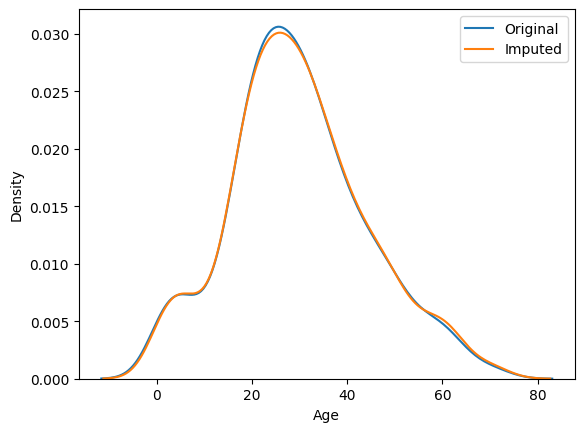

In [30]:
sns.kdeplot(X_train['Age'], label='Original')
sns.kdeplot(X_train['Age_imputed'], label='Imputed')

plt.legend()
plt.show()

In [31]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  204.3495133904614
Variance after random imputation:  208.48897834905745


In [32]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,51.472684
Age,71.512440,204.349513,204.349513
Age_imputed,51.472684,204.349513,208.488978


<Axes: >

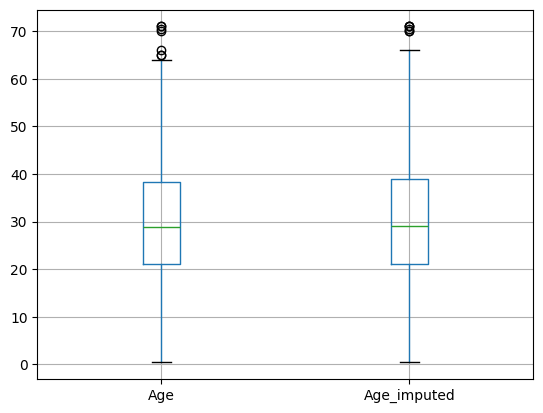

In [33]:
X_train[['Age', 'Age_imputed']].boxplot()

In [ ]:
#sampled_value = X_train['Age'].dropna().sample(1, random_state=int(observation['Fare']))  Here when i choose random no for diff user choosing same input should give same random no so we take fare as standard for it

In [34]:
data = pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [35]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [36]:
data.isnull().mean() * 100

,0
FireplaceQu,47.260274
GarageQual,5.547945
SalePrice,0.000000


In [37]:
X = data
y = data['SalePrice']

In [38]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [39]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [40]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
242,NaN,Fa,79000,Fa,NaN
257,Gd,TA,220000,TA,Gd
992,Fa,TA,187000,TA,Fa
1221,TA,TA,134000,TA,TA
870,NaN,TA,109500,TA,NaN


In [44]:
# -------------------- GarageQual --------------------
# For X_train
missing_train = X_train['GarageQual_imputed'].isnull().sum()

X_train.loc[X_train['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = (
    X_train['GarageQual'].dropna()
    .sample(missing_train, replace=True, random_state=0)
    .values
)

# For X_test
missing_test = X_test['GarageQual_imputed'].isnull().sum()

X_test.loc[X_test['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = (
    X_train['GarageQual'].dropna()
    .sample(missing_test, replace=True, random_state=0)
    .values
)

# -------------------- FireplaceQu --------------------
# For X_train
missing_train = X_train['FireplaceQu_imputed'].isnull().sum()

X_train.loc[X_train['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = (
    X_train['FireplaceQu'].dropna()
    .sample(missing_train, replace=True, random_state=0)
    .values
)

# For X_test
missing_test = X_test['FireplaceQu_imputed'].isnull().sum()

X_test.loc[X_test['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = (
    X_train['FireplaceQu'].dropna()
    .sample(missing_test, replace=True, random_state=0)
    .values
)


In [45]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [47]:
temp  # Here almost percent change after imputation is negligable so its good imputation to use here

,original,imputed
TA,0.951043,0.951199
Fa,0.037171,0.036815
Gd,0.009973,0.010274
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [49]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp      # Here  percent change so much  after imputation  so its not good imputation model to use here

,original,imputed
Gd,0.494272,0.647587
TA,0.412439,0.542088
Fa,0.040917,0.054994
Po,0.027823,0.034792
Ex,0.024550,0.031425


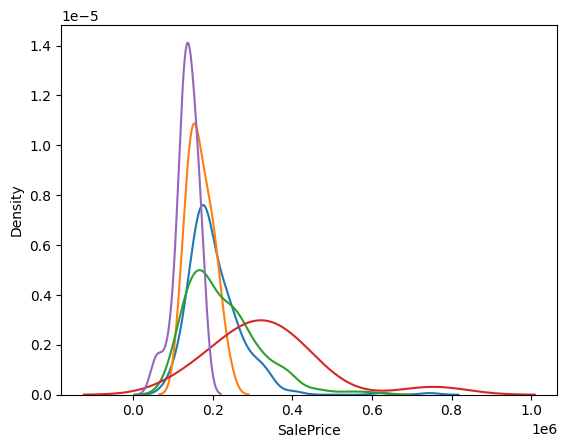

In [52]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],label=category)
plt.show()

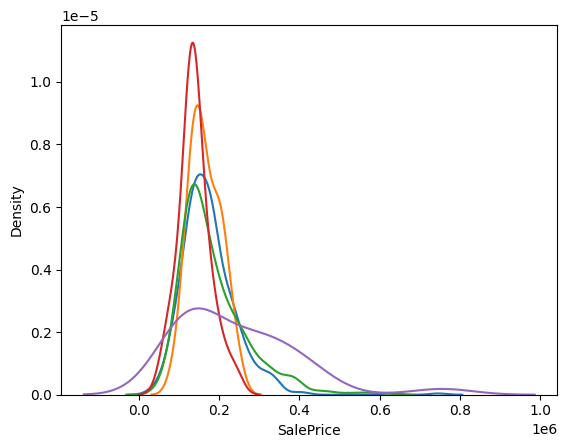

In [53]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],label=category)
plt.show()